# STT Benchmark Report — Multi-Condition Evaluation

## Overview

This notebook evaluates speech-to-text (STT) performance across multiple real-world audio degradation conditions using a controlled dataset and Word Error Rate (WER) as the primary metric.

### Dataset
- 12 Common Voice speech clips
- Identical source clips used across all conditions

### STT Engine
- OpenAI `gpt-4o-mini-transcribe`

### Conditions Evaluated
- Clean (baseline)
- Broadband Noise
- MP3 Compression (64 kbps)
- Reverb (temporal smearing)
- Combined (Noise + Codec)

---

## Objective

To understand how different types of audio degradation impact transcription accuracy, and to identify:

- **Failure modes** (where the system breaks)
- **Robustness zones** (where performance holds)
- **Interaction effects** between degradations

---

## Key Question

> Do different types of degradation affect STT equally, or do some conditions expose deeper system weaknesses?

In [1]:
import pandas as pd
from jiwer import wer
import matplotlib.pyplot as plt

In [2]:
# Load benchmark outputs
clean = pd.read_csv("../benchmark_output/openai_clean_final_results.csv")
noisy = pd.read_csv("../benchmark_output/openai_noisy_results.csv")
codec = pd.read_csv("../benchmark_output/openai_codec_results.csv")
combined = pd.read_csv("../benchmark_output/openai_combined_results.csv")
reverb = pd.read_csv("../benchmark_output/openai_reverb_results.csv")

# Remove aggregate row from clean results
clean = clean[clean["audio_file"] != "AVERAGE"]

In [3]:
# Drop failed noisy samples (no transcript returned)
noisy_valid = noisy.dropna(subset=["reference_text", "hypothesis_text"]).copy()

In [4]:
# Compute WER for each condition
noisy_valid["wer"] = noisy_valid.apply(lambda r: wer(r["reference_text"], r["hypothesis_text"]), axis=1)
codec["wer"] = codec.apply(lambda r: wer(r["reference_text"], r["hypothesis_text"]), axis=1)
combined["wer"] = combined.apply(lambda r: wer(r["reference_text"], r["hypothesis_text"]), axis=1)
reverb["wer"] = reverb.apply(lambda r: wer(r["reference_text"], r["hypothesis_text"]), axis=1)

## Results Summary

In [5]:
# Compute averages
clean_avg = clean["wer"].mean()
noisy_avg = noisy_valid["wer"].mean()
codec_avg = codec["wer"].mean()
combined_avg = combined["wer"].mean()
reverb_avg = reverb["wer"].mean()

print("Clean WER:", round(clean_avg, 4))
print("Noisy WER:", round(noisy_avg, 4))
print("Codec WER:", round(codec_avg, 4))
print("Combined WER:", round(combined_avg, 4))
print("Reverb WER:", round(reverb_avg, 4))

Clean WER: 0.1124
Noisy WER: 0.3708
Codec WER: 0.1184
Combined WER: 0.4552
Reverb WER: 0.1078


## Delta Analysis

In [6]:
print("\nΔ Noise vs Clean:", round(noisy_avg - clean_avg, 4))
print("Δ Codec vs Clean:", round(codec_avg - clean_avg, 4))
print("Δ Combined vs Clean:", round(combined_avg - clean_avg, 4))
print("Δ Reverb vs Clean:", round(reverb_avg - clean_avg, 4))

print("\nValid noisy rows:", len(noisy_valid))
print("Dropped noisy rows:", len(noisy) - len(noisy_valid))


Δ Noise vs Clean: 0.2584
Δ Codec vs Clean: 0.006
Δ Combined vs Clean: 0.3428
Δ Reverb vs Clean: -0.0046

Valid noisy rows: 9
Dropped noisy rows: 3


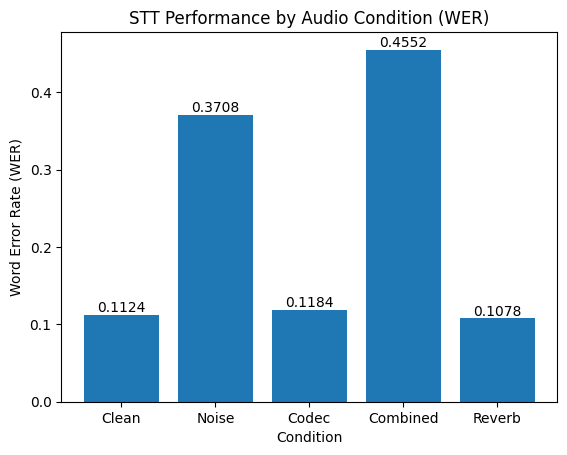

In [7]:
conditions = ["Clean", "Noise", "Codec", "Combined", "Reverb"]
wer_values = [clean_avg, noisy_avg, codec_avg, combined_avg, reverb_avg]

plt.figure()
plt.bar(conditions, wer_values)

plt.title("STT Performance by Audio Condition (WER)")
plt.xlabel("Condition")
plt.ylabel("Word Error Rate (WER)")

for i, v in enumerate(wer_values):
    plt.text(i, v, str(round(v, 4)), ha='center', va='bottom')

plt.show()

## Interpretation

### 1. Noise Dominates Failure
Broadband noise produces a large increase in WER (+0.2584) and introduces complete transcription failures.

### 2. Codec is Highly Tolerated
MP3 compression (64 kbps) shows minimal impact on transcription accuracy, indicating robustness to lossy encoding artifacts.

### 3. Reverb Has Minimal Impact (Moderate Levels)
Reverb does not introduce measurable degradation in WER, suggesting the system is resilient to temporal smearing when intelligibility remains intact.

### 4. Stacked Degradations Amplify Failure
The combined condition (noise + codec) produces the worst performance (WER = 0.4552), demonstrating that degradation interactions can compound system failure.

### 5. Key Insight
Not all audio degradation is equally harmful:

- **Masking (noise)** → highly destructive  
- **Compression (codec)** → largely tolerated  
- **Temporal smearing (reverb)** → tolerated at moderate levels  
- **Stacked effects** → significantly amplify failure  

---

## Conclusion

This benchmark shows that evaluating degradations in isolation is insufficient.

Real-world performance is better understood through:
- **multi-condition testing**
- **controlled comparisons**
- **interaction analysis**

---

## Current Scope

This phase of the benchmark focuses on:

- Single STT engine evaluation  
- Multi-condition robustness testing  
- WER as the primary comparison metric  

---

## Future Work

Potential expansions:

- Multi-engine comparison (Whisper, Google STT, AssemblyAI)
- Additional metrics (CER, substitution/deletion analysis)
- Noise reduction pipeline evaluation
- More complex degradation combinations

---